<a href="https://colab.research.google.com/github/Smeerz99/northstar-analytics-coursework/blob/main/notebooks/03_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## R Analytics

This notebooks uses R to carry out analytical exploration of the NorthStar datasets. The aim of this notebook is to use statistical summaries and visualisation to identify patterns in delviery performance, customer satisfaction, and operational inefficiency.

In [1]:
!apt-get -qq update
!apt-get -qq install -y r-base r-cran-readr r-cran-dplyr r-cran-ggplot2 r-cran-tidyr
!pip -q install rpy2
%load_ext rpy2.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../r-cran-dplyr_1.2.1-1.ca2204.1_amd64.deb ...
Unpacking r-cran-dplyr (1.2.1-1.ca2204.1) over (1.2.0-1.ca2204.1) ...
Setting up r-cran-dplyr (1.2.1-1.ca2204.1) ...


In [2]:
%%R
library(readr)
library(dplyr)
library(ggplot2)
library(tidyr)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



## Loading and combining the datasets

The datasets were loaded into R and combined to support visual and statistical analysis of operational performance. The main focus is on linking delivery outcomes with order, vehicle, hub, and customer-related variables.

In [3]:
%%R
orders <- read_csv("/content/orders.csv", show_col_types = FALSE)
deliveries <- read_csv("/content/deliveries.csv", show_col_types = FALSE)
customers <- read_csv("/content/customers.csv", show_col_types = FALSE)
vehicles <- read_csv("/content/vehicles.csv", show_col_types = FALSE)
hubs <- read_csv("/content/hubs.csv", show_col_types = FALSE)
complaints <- read_csv("/content/complaints.csv", show_col_types = FALSE)

analysis_r <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  left_join(customers, by = "customer_id") %>%
  left_join(vehicles, by = "vehicle_id") %>%
  left_join(hubs, by = "hub_id")

head(analysis_r)

# A tibble: 6 × 42
  delivery_id order_id driver_id vehicle_id hub_id dispatch_time      
  <chr>       <chr>    <chr>     <chr>      <chr>  <dttm>             
1 DL00001     O00938   D004      V056       H05    2024-06-18 10:57:00
2 DL00002     O00004   D138      V007       H02    2025-01-11 18:45:00
3 DL00003     O00639   D006      V049       H02    2025-06-02 20:39:00
4 DL00004     O00313   D116      V055       H02    2024-03-08 23:31:00
5 DL00005     O00844   D108      V034       H01    2025-09-21 11:43:00
6 DL00006     O00029   D037      V098       H03    2024-09-11 12:40:00
# ℹ 36 more variables: delivery_completed_at <dttm>, delivery_status <chr>,
#   route_distance_km <dbl>, manual_route_override_count <dbl>,
#   proof_of_completion_missing <dbl>, customer_rating_post_delivery <dbl>,
#   fuel_or_charge_cost <dbl>, customer_id <chr>, service_type <chr>,
#   order_created_at <dttm>, promised_window_hours <dbl>, pickup_zone <chr>,
#   dropoff_zone <chr>, priority_level <chr>, orde

## Preparing variables

Before createing any visuals, the datetime fields were converted and a delivery duration measure was created. This makes is possible to compare operational performance across service categories and outcomes.

In [4]:
%%R
analysis_r <- analysis_r %>%
  mutate(
    dispatch_time = as.POSIXct(dispatch_time),
    delivery_completed_at = as.POSIXct(delivery_completed_at),
    delivery_duration_hours = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours"))
  )

summary(analysis_r$delivery_duration_hours)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 -2.214   2.946   7.074   9.545  14.644  43.457      19 


## Visual 1: Delivery outcomes by hub zone

This chart compares delivery outcomes across hub zones to identify whether some parts of the netwrok are performing worse than others.

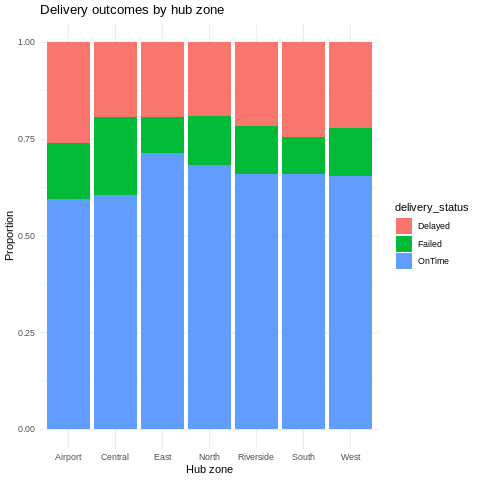

In [5]:
%%R
ggplot(analysis_r, aes(x = zone, fill = delivery_status)) +
  geom_bar(position = "fill") +
  labs(
    title = "Delivery outcomes by hub zone",
    x = "Hub zone",
    y = "Proportion"
  ) +
  theme_minimal()

## Interpretation

This visual shows if delayed and failed deliveries are connected in certain zones, Differences across zones could suggest local operational issues such as hub pressure, route problems, or weaker vehicle availability.

## Visual 2: Delivery duration by service type

Delivery duration was compared across service types to explore whether some types of service are more time consuming or less efficient than others.


(`stat_boxplot()`). 



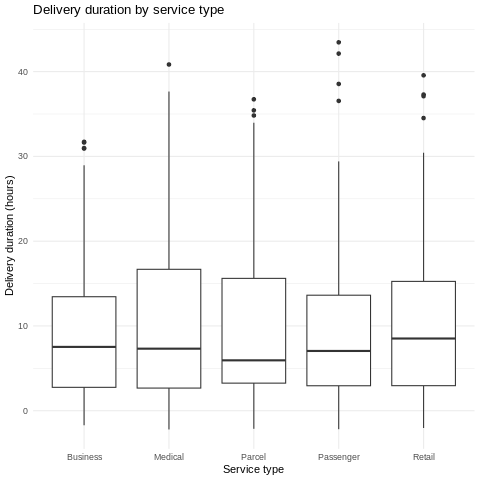

In [6]:
%%R
ggplot(analysis_r, aes(x = service_type, y = delivery_duration_hours)) +
  geom_boxplot() +
  labs(
    title = "Delivery duration by service type",
    x = "Service type",
    y = "Delivery duration (hours)"
  ) +
  theme_minimal()

## Interpretation

This chart shows if some service types take longer to complete than others. Larger spread or higher median duration could suggest that certain service categories are harder to manage or more vulnerable to operational delay.

## Visual 3: Customer rating by delivery outcome

Customer ratings are deliveries were examined across different delivery outcomes to see if operational performance affects customer satisfaction.


(`stat_boxplot()`). 



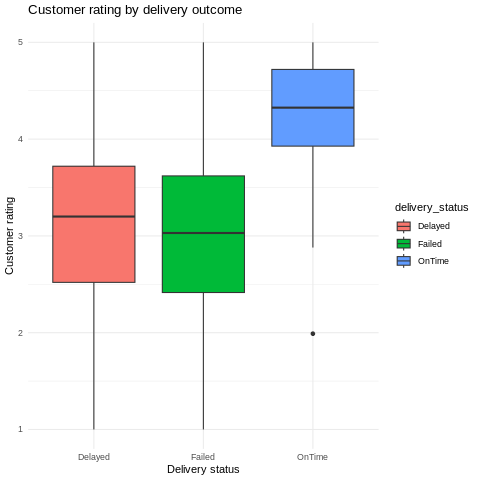

In [7]:
%%R
ggplot(analysis_r, aes(x = delivery_status, y = customer_rating_post_delivery, fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Customer rating by delivery outcome",
    x = "Delivery status",
    y = "Customer rating"
  ) +
  theme_minimal()

## Interpretation

This visual helps show if delayed or failed deliveries are associated with weaker customer ratings. Lower ratings for poorer delivery outcomes would support the view that operational inefficiency is directly affecting customers experience.

## Visual 4: Manual route overrieds by delivery outcomes

Manual route override counts were comapred across delivery outcomes to explore if route instability is linked to delays and failures.

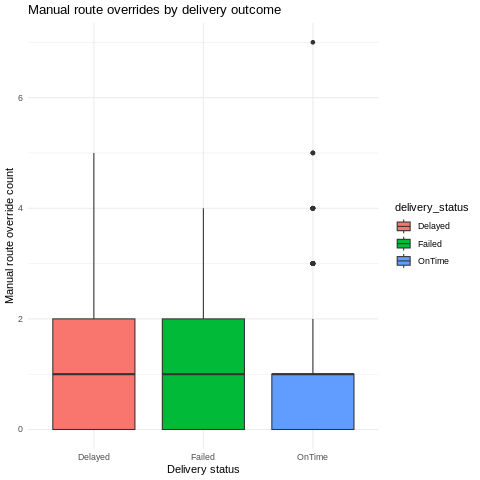

In [8]:
%%R
ggplot(analysis_r, aes(x = delivery_status, y = manual_route_override_count, fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Manual route overrides by delivery outcome",
    x = "Delivery status",
    y = "Manual route override count"
  ) +
  theme_minimal()

## Interpretation

If delayed or failed deliveries show a higher route override count, it can suggest that route disruption, replanning, or weak initial allocation is contributing to poor service performance.

## Complaints by delivery outcomes

Complaint data was sumamries and linked to delivery outcomes in order to compare customer dissatisfaction across operational results,

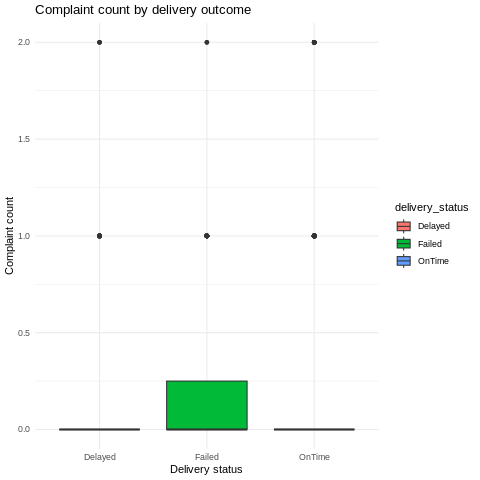

In [9]:
%%R
complaint_summary <- complaints %>%
  group_by(order_id) %>%
  summarise(complaint_count = n(), .groups = "drop")

analysis_r2 <- analysis_r %>%
  left_join(complaint_summary, by = "order_id") %>%
  mutate(complaint_count = ifelse(is.na(complaint_count), 0, complaint_count))

ggplot(analysis_r2, aes(x = delivery_status, y = complaint_count, fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Complaint count by delivery outcome",
    x = "Delivery status",
    y = "Complaint count"
  ) +
  theme_minimal()

## Interpretation

This analysis shows whether delayed or failed deliveries are more likely to lead to customer complaints. Higher complain counts for pooper delivery outcomes would show that operational problems are visible to customers and are affecting service quality.

## Summary

The R analytics section extends the SQL and Python work by using visual analysis to explore patterns in service performance, customer ratings, complaints, and route instability. Together, these results help identify the factors that are linked to the delays, failures, and customer dissatisfaction.   